In [37]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [21]:
with open("token_to_number_combined.json", "r") as f:
    token_to_number_combined = json.load(f)
with open("number_to_token_combined.json", "r") as f:
    number_to_token_combined = json.load(f)

In [22]:
df = pd.read_json("CleanData(Tokenized).json", orient="records")
df

,string,band_gap,energy_above_hull,tokens,tokenized
0,P 4bar n 2 Tb 4f 0.355 0.000 0.000,0.0000,0.000000,"[START, P, 4bar, n, 2, Tb, 4f, 3, 5, 5, 0, 0, ...","[13, 15, 101, 81, 47, 107, 58, 2, 8, 8, 1, 1, ..."
1,P 6bar 1 1 Eu 2g 0.000 0.000 0.545 C 2g 0.000 ...,0.0000,0.000000,"[START, P, 6bar, 1, 1, Eu, 2g, 0, 0, 0, 0, 0, ...","[13, 15, 89, 17, 17, 145, 152, 1, 1, 1, 1, 1, ..."
2,I 4bar c 2 Tl 4a 0.000 0.000 0.000 Cl 8f 0.000...,0.0000,0.000000,"[START, I, 4bar, c, 2, Tl, 4a, 0, 0, 0, 0, 0, ...","[13, 34, 101, 24, 47, 122, 27, 1, 1, 1, 1, 1, ..."
3,P m c 21 Kr 4c 0.595 0.217 0.468 Tb 2a 0.000 0...,0.0000,0.000000,"[START, P, m, c, 21, Kr, 4c, 5, 9, 5, 2, 1, 7,...","[13, 15, 11, 24, 104, 277, 33, 8, 10, 8, 6, 3,..."
4,P 3bar 1 c Co 2c 0.000 0.000 0.000,0.0000,0.000000,"[START, P, 3bar, 1, c, Co, 2c, 0, 0, 0, 0, 0, ...","[13, 15, 20, 17, 24, 72, 52, 1, 1, 1, 1, 1, 1,..."
...,...,...,...,...,...
19084,C m c m Ba 4c 0.000 0.14 0.000 Si 4c 0.000 0.4...,0.0000,0.000000,"[START, C, m, c, m, Ba, 4c, 0, 0, 0, 1, 4, 0, ...","[13, 40, 11, 24, 11, 129, 33, 1, 1, 1, 3, 9, 1..."
19085,C m c m V 8f 0.000 0.296 0.604 O 4c 0.000 0.76...,2.4212,0.032813,"[START, C, m, c, m, V, 8f, 0, 0, 0, 2, 9, 6, 6...","[13, 40, 11, 24, 11, 71, 38, 1, 1, 1, 6, 10, 4..."
19086,C m c m Na 4c 0.000 0.178 0.000 Na 4c 0.000 0....,0.0000,0.000000,"[START, C, m, c, m, Na, 4c, 0, 0, 0, 1, 7, 8, ...","[13, 40, 11, 24, 11, 106, 33, 1, 1, 1, 3, 5, 7..."
19087,C m c m Nb 4c 0.000 0.145 0.000 B 4c 0.000 0.4...,0.0000,0.000000,"[START, C, m, c, m, Nb, 4c, 0, 0, 0, 1, 4, 5, ...","[13, 40, 11, 24, 11, 85, 33, 1, 1, 1, 3, 9, 8,..."


In [24]:
max_sequence_len = max([len(seq) for seq in df['tokenized']])
X = np.array(pad_sequences(df['tokenized'], maxlen=max_sequence_len, padding="post"))

In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

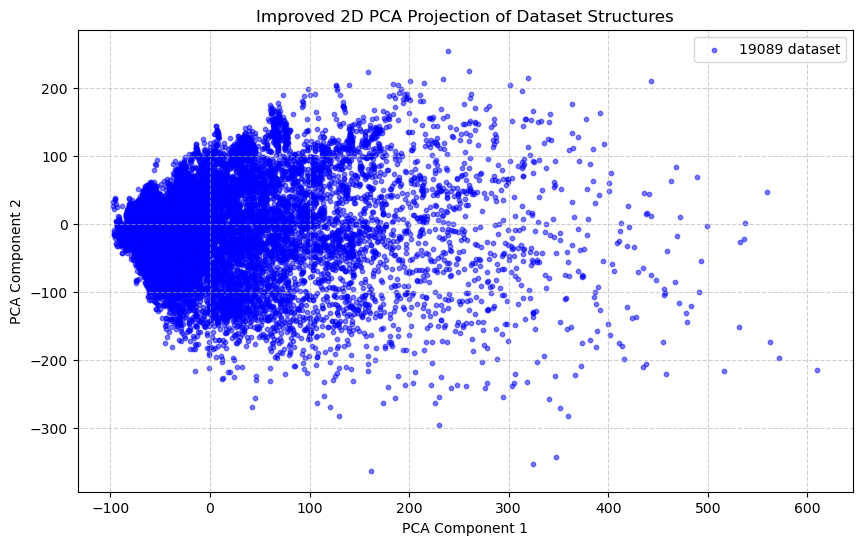

In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', s=10, alpha=0.5, label=f"{df.shape[0]} dataset")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Improved 2D PCA Projection of Dataset Structures")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

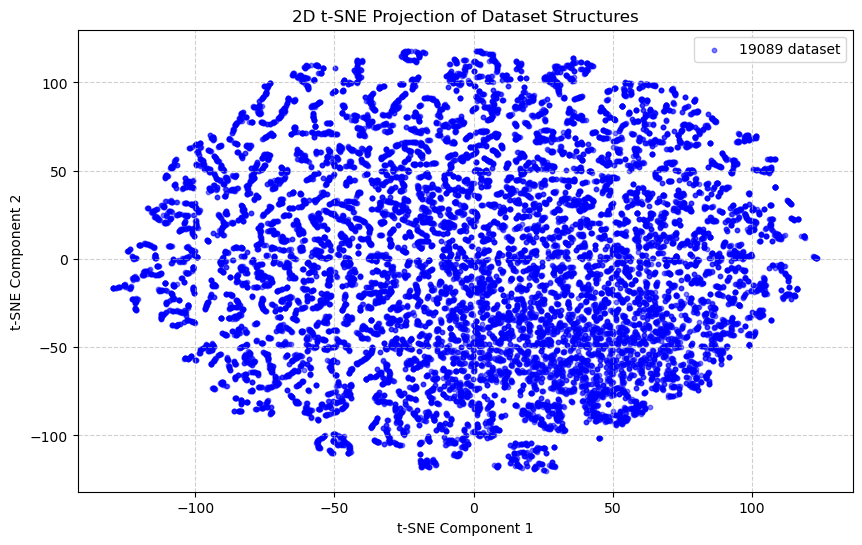

In [38]:
tsne = TSNE(n_components=2, perplexity=10)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c='blue', s=10, alpha=0.5, label=f"{df.shape[0]} dataset")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("2D t-SNE Projection of Dataset Structures")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()